In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("test_170_EVE20377083_data.csv")
df

,atime,seqid,cycleid,stepid,steptype,testtime,voltage,current,capacity,energy
0,2026-02-18T12:43:14,1,NaN,1,cccv,NaN,3.599166,6.649621,0.000000,0.000000
1,2026-02-18T12:43:19,2,NaN,1,cccv,4500.0,3.650159,0.986626,0.004980,0.018102
2,2026-02-18T12:43:19,3,NaN,2,rest,NaN,3.648619,0.000000,0.000000,0.000000
3,2026-02-18T12:43:49,4,NaN,2,rest,30000.0,3.623402,0.000000,0.000000,0.000000
4,2026-02-18T12:44:19,5,NaN,2,rest,60000.0,3.616790,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
518328,2026-08-17T17:50:18,518343,785.0,1,cccv,1080000.0,3.257107,6.650732,1.994809,6.281204
518329,2026-08-17T17:50:48,518344,785.0,1,cccv,1110000.0,3.258016,6.652752,2.050219,6.461710
518330,2026-08-17T17:51:18,518345,785.0,1,cccv,1140000.0,3.259116,6.646351,2.105630,6.642275
518331,2026-08-17T17:51:48,518346,785.0,1,cccv,1170000.0,3.260346,6.648073,2.161042,6.822903


In [3]:
df["cycleid"].max()

785.0

In [4]:
df.describe()

,seqid,cycleid,stepid,testtime,voltage,current,capacity,energy
count,518333.000000,518027.000000,518333.000000,5.151920e+05,518333.000000,518333.000000,518333.000000,518333.000000
mean,259174.224290,395.328566,1.926231,4.193500e+06,3.273817,-0.046709,8.797844,28.874457
std,149635.656549,227.955054,1.043290,2.903744e+06,0.188365,7.627451,6.020156,19.849889
min,1.000000,1.000000,1.000000,4.500000e+03,2.498854,-9.913432,0.000000,0.000000
25%,129584.000000,197.000000,1.000000,1.590000e+06,3.239018,-9.897483,3.381920,10.978601
50%,259174.000000,396.000000,1.000000,3.990000e+06,3.295832,6.645181,8.743523,28.639469
75%,388764.000000,597.000000,3.000000,6.330000e+06,3.369701,6.649446,13.940173,45.875793
max,518347.000000,785.000000,4.000000,1.081430e+07,3.650320,6.664422,19.873379,66.052513


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

atime          0
seqid          0
cycleid      306
stepid         0
steptype       0
testtime    3141
voltage        0
current        0
capacity       0
energy         0
dtype: int64

In [7]:
df.dropna(subset=["cycleid"])

,atime,seqid,cycleid,stepid,steptype,testtime,voltage,current,capacity,energy
306,2026-02-18T15:13:34,307,1.0,1,cccv,NaN,2.857571,6.646416,0.000000,0.000000
307,2026-02-18T15:14:04,308,1.0,1,cccv,30000.0,2.923482,6.648785,0.055410,0.160512
308,2026-02-18T15:14:34,309,1.0,1,cccv,60000.0,2.963196,6.648472,0.110821,0.323651
309,2026-02-18T15:15:04,310,1.0,1,cccv,90000.0,2.995612,6.646445,0.166232,0.488770
310,2026-02-18T15:15:34,311,1.0,1,cccv,120000.0,3.023518,6.651423,0.221644,0.655553
...,...,...,...,...,...,...,...,...,...,...
518328,2026-08-17T17:50:18,518343,785.0,1,cccv,1080000.0,3.257107,6.650732,1.994809,6.281204
518329,2026-08-17T17:50:48,518344,785.0,1,cccv,1110000.0,3.258016,6.652752,2.050219,6.461710
518330,2026-08-17T17:51:18,518345,785.0,1,cccv,1140000.0,3.259116,6.646351,2.105630,6.642275
518331,2026-08-17T17:51:48,518346,785.0,1,cccv,1170000.0,3.260346,6.648073,2.161042,6.822903


In [8]:
df1=df.groupby(["cycleid","steptype"])[["steptype","voltage","current","capacity","energy"]].max()

In [9]:
df1=df1[0:2352]
df1

steptype   voltage   current   capacity     energy
cycleid steptype                                                   
1.0     cccv         cccv  3.650159  6.660534  19.604925  65.827644
        dc             dc  3.480183 -9.890347  19.826941  63.457012
        rest         rest  3.648489  0.000000   0.000000   0.000000
2.0     cccv         cccv  3.650219  6.660876  19.686865  65.996513
        dc             dc  3.497827 -9.891539  19.864605  63.659859
...                   ...       ...       ...        ...        ...
783.0   dc             dc  3.508011 -9.891169  18.986927  60.954731
        rest         rest  3.648909  0.000000   0.000000   0.000000
784.0   cccv         cccv  3.650110  6.660774  18.841356  62.983715
        dc             dc  3.514081 -9.886220  18.988873  60.947517
        rest         rest  3.648979  0.000000   0.000000   0.000000

[2352 rows x 5 columns]

In [10]:
df2=df.groupby("cycleid")[["steptype","voltage","current"]].min()
df2=df2[0:784]
df2

/var/folders/nd/psf542414zsgyx3srrrg7frw0000gn/T/ipykernel_69938/1144246429.py:2: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df2=df2[0:784]


,steptype,voltage,current
cycleid,,,
1.0,cccv,2.499424,-9.908128
2.0,cccv,2.499954,-9.907132
3.0,cccv,2.499704,-9.908628
4.0,cccv,2.499304,-9.907060
5.0,cccv,2.499604,-9.910852
...,...,...,...
780.0,cccv,2.499164,-9.909857
781.0,cccv,2.499124,-9.906013
782.0,cccv,2.499114,-9.908381


In [16]:
df3=df.groupby(["cycleid"])[["steptype","voltage","current","capacity"]].max()
df3=df3[0:784]
df3

/var/folders/nd/psf542414zsgyx3srrrg7frw0000gn/T/ipykernel_69938/394413536.py:2: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df3=df3[0:784]


,steptype,voltage,current,capacity
cycleid,,,,
1.0,rest,3.650159,6.660534,19.826941
2.0,rest,3.650219,6.660876,19.864605
3.0,rest,3.650099,6.661036,19.836855
4.0,rest,3.650119,6.662786,19.813181
5.0,rest,3.650129,6.657264,19.806309
...,...,...,...,...
780.0,rest,3.650049,6.660534,19.008932
781.0,rest,3.650129,6.656305,19.007566
782.0,rest,3.650159,6.659270,19.006748


In [17]:
max_capacity = df3["capacity"].max()

df3["soh"] = (df3["capacity"] / max_capacity) * 100

In [18]:
df3

,steptype,voltage,current,capacity,soh
cycleid,,,,,
1.0,rest,3.650159,6.660534,19.826941,99.766330
2.0,rest,3.650219,6.660876,19.864605,99.955851
3.0,rest,3.650099,6.661036,19.836855,99.816217
4.0,rest,3.650119,6.662786,19.813181,99.697093
5.0,rest,3.650129,6.657264,19.806309,99.662513
...,...,...,...,...,...
780.0,rest,3.650049,6.660534,19.008932,95.650228
781.0,rest,3.650129,6.656305,19.007566,95.643356
782.0,rest,3.650159,6.659270,19.006748,95.639239


In [19]:
df3=df3.reset_index()

In [20]:
df3

,cycleid,steptype,voltage,current,capacity,soh
0,1.0,rest,3.650159,6.660534,19.826941,99.766330
1,2.0,rest,3.650219,6.660876,19.864605,99.955851
2,3.0,rest,3.650099,6.661036,19.836855,99.816217
3,4.0,rest,3.650119,6.662786,19.813181,99.697093
4,5.0,rest,3.650129,6.657264,19.806309,99.662513
...,...,...,...,...,...,...
779,780.0,rest,3.650049,6.660534,19.008932,95.650228
780,781.0,rest,3.650129,6.656305,19.007566,95.643356
781,782.0,rest,3.650159,6.659270,19.006748,95.639239
782,783.0,rest,3.650090,6.659503,18.986927,95.539502


In [21]:
x=df3[["cycleid","voltage","current"]]
x

,cycleid,voltage,current
0,1.0,3.650159,6.660534
1,2.0,3.650219,6.660876
2,3.0,3.650099,6.661036
3,4.0,3.650119,6.662786
4,5.0,3.650129,6.657264
...,...,...,...
779,780.0,3.650049,6.660534
780,781.0,3.650129,6.656305
781,782.0,3.650159,6.659270
782,783.0,3.650090,6.659503


In [22]:
y=df3["soh"]
y

0      99.766330
1      99.955851
2      99.816217
3      99.697093
4      99.662513
         ...    
779    95.650228
780    95.643356
781    95.639239
782    95.539502
783    95.549291
Name: soh, Length: 784, dtype: float64

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error



model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [26]:
y_pred

array([96.31631802, 96.35597894, 98.3307325 , 96.11623627, 98.49697801,
       98.30603388, 97.18413772, 98.06276261, 96.33001831, 98.35395638,
       96.41912071, 98.15119523, 98.1917197 , 98.27229346, 95.43491134,
       98.61676281, 96.74747541, 99.0787007 , 96.41677275, 98.83052335,
       99.05365992, 96.71901621, 99.00292946, 96.9671463 , 99.2779065 ,
       98.31965523, 95.75712463, 97.11490459, 96.06936585, 99.20079335,
       97.68868774, 98.9435672 , 98.69427258, 96.03066765, 96.01020295,
       97.13400377, 96.7001863 , 96.74457386, 97.67184184, 96.14967449,
       97.64104081, 95.38787282, 98.78844633, 96.05031736, 98.06247906,
       95.3699539 , 97.58180721, 97.21050632, 98.99480675, 95.83793239,
       96.90885335, 95.86953344, 99.15612627, 96.72872113, 98.53487974,
       97.73258562, 97.43627946, 97.4706121 , 96.48788349, 97.79702201,
       96.15846643, 99.25056308, 97.53808508, 99.2396277 , 99.22655997,
       96.15934983, 96.51400776, 97.30360152, 98.09646016, 97.28

In [27]:
print("R2 =", r2_score(y_test, y_pred))
print("MSE =", mean_squared_error(y_test, y_pred))

R2 = 0.980802968641443
MSE = 0.025831045421450566


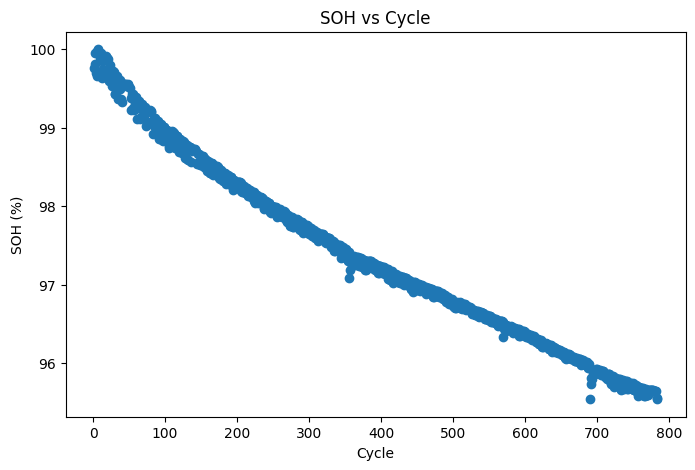

In [28]:
y_pred = model.predict(X_test)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df3["cycleid"], df3["soh"])

plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title("SOH vs Cycle")

plt.show()

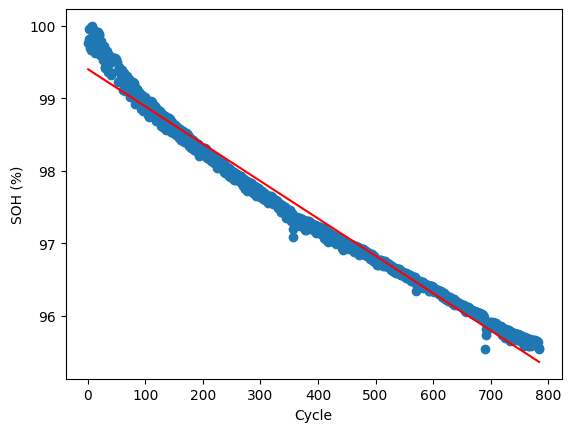

In [29]:
from sklearn.linear_model import LinearRegression

X = df3["cycleid"].values.reshape(-1, 1)
y = df3["soh"]

model = LinearRegression()
model.fit(X, y)

y_fit = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_fit,color="red")
plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.show()

In [30]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.995456244844563
MSE: 0.006113963331717238


In [31]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9972618130757679
MSE: 0.00368443586360732


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9972920626898448
MSE: 0.0036437327392226638


In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9947977988806549
MSE: 0.006999951757927677


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),

    "Polynomial Regression": make_pipeline(
        PolynomialFeatures(degree=4),
        LinearRegression()
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,MSE,RMSE,MAE
0,Gradient Boosting,0.997292,0.003644,0.060363,0.045854
1,Polynomial Regression,0.997275,0.003666,0.060551,0.049240
2,Random Forest,0.997262,0.003684,0.060700,0.046975
3,Decision Tree,0.995456,0.006114,0.078192,0.056038
4,Linear Regression,0.980803,0.025831,0.160720,0.127992


In [35]:
results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

results_df

,Model,R2,MSE,RMSE,MAE
0,Gradient Boosting,0.997292,0.003644,0.060363,0.045854
1,Polynomial Regression,0.997275,0.003666,0.060551,0.049240
2,Random Forest,0.997262,0.003684,0.060700,0.046975
3,Decision Tree,0.995456,0.006114,0.078192,0.056038
4,Linear Regression,0.980803,0.025831,0.160720,0.127992


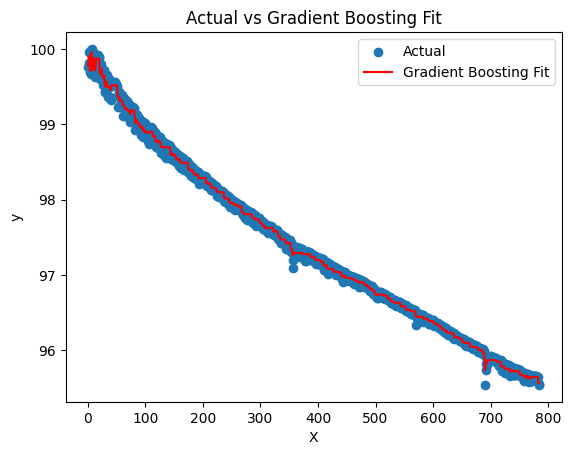

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(X, y)

y_pred = model.predict(X)

idx = np.argsort(X[:, 0])

plt.scatter(X[:, 0], y, label="Actual")
plt.plot(X[idx, 0], y_pred[idx], label="Gradient Boosting Fit",color="red")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Actual vs Gradient Boosting Fit")
plt.legend()
plt.show()

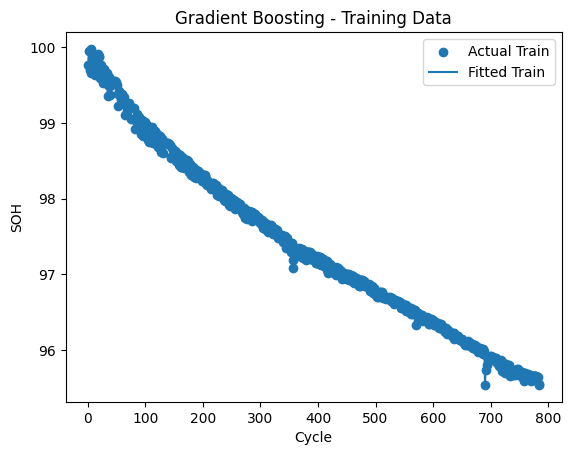

In [37]:
idx = np.argsort(X_train.iloc[:, 0])

plt.scatter(X_train.iloc[:, 0], y_train, label="Actual Train")
plt.plot(
    X_train.iloc[idx, 0],
    y_train.iloc[idx],
    label="Fitted Train"
)

plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Gradient Boosting - Training Data")
plt.legend()
plt.show()

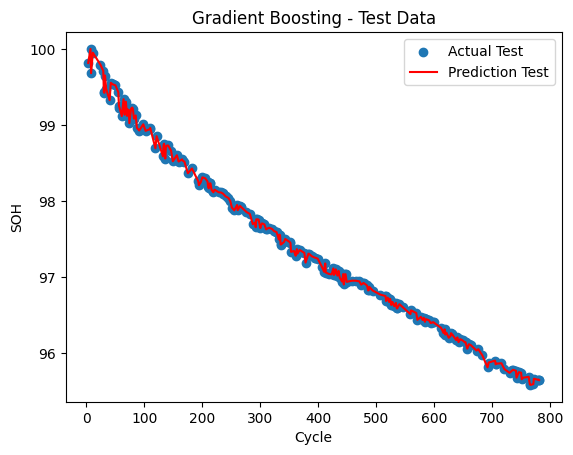

In [38]:
idx = np.argsort(X_test.iloc[:, 0])

plt.scatter(X_test.iloc[:, 0], y_test, label="Actual Test")
plt.plot(
    X_test.iloc[idx, 0],
    y_test.iloc[idx],
    label="Prediction Test",
    color="red"
)

plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Gradient Boosting - Test Data")
plt.legend()
plt.show()

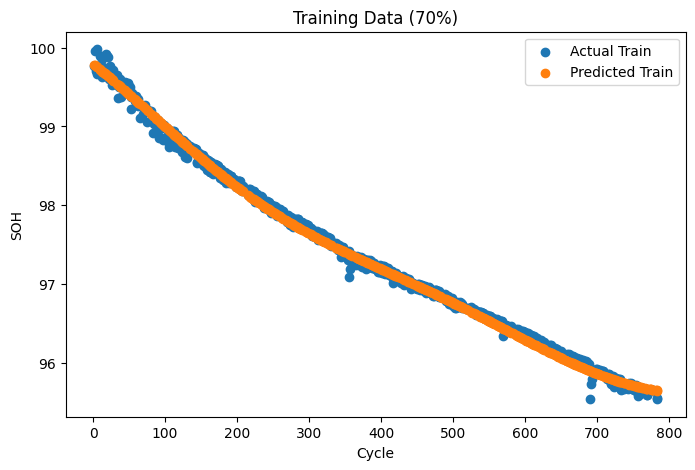

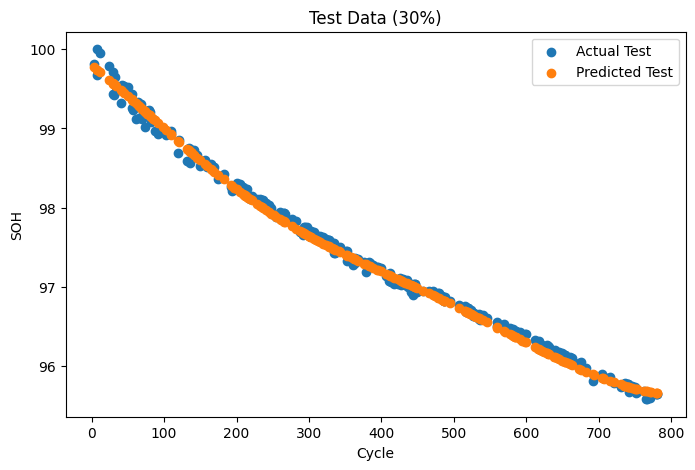

In [51]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Train Graph
plt.figure(figsize=(8,5))
plt.scatter(X_train.iloc[:, 0], y_train, label="Actual Train")
plt.scatter(X_train.iloc[:, 0], y_train_pred, label="Predicted Train")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Training Data (70%)")
plt.legend()
plt.show()

# Test Graph
plt.figure(figsize=(8,5))
plt.scatter(X_test.iloc[:, 0], y_test, label="Actual Test")
plt.scatter(X_test.iloc[:, 0], y_test_pred, label="Predicted Test")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Test Data (30%)")
plt.legend()
plt.show()

In [40]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9947977988806549
MSE: 0.006999951757927677


In [52]:
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression


# poly = PolynomialFeatures(degree=3)

# X_train_poly = poly.fit_transform(X_train)
# X_test_poly = poly.transform(X_test)


# poly_model = LinearRegression()

# poly_model.fit(X_train_poly, y_train)


# train_pred = poly_model.predict(X_train_poly)
# test_pred = poly_model.predict(X_test_poly)

# # train graph - 70%
# idx = np.argsort(X_train[:, 0])

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     X_train[:, 0],
#     y_train,
#     label="Actual Train"
# )

# plt.plot(
#     X_train[idx, 0],
#     train_pred[idx],
#     label="Polynomial Fit",
#     color="red"
# )

# plt.xlabel("Cycle")
# plt.ylabel("SOH")
# plt.title("Polynomial Regression - Training Data (70%)")
# plt.legend()
# plt.show()


# # test graph - 30%

# idx = np.argsort(X_test[:, 0])

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     X_test.iloc[:, 0],
#     y_test,
#     label="Actual Test"
# )

# plt.plot(
#     X_test.iloc[:, 0],
#     test_pred[idx],
#     label="Prediction",
#     color="red"
# )

# plt.xlabel("Cycle")
# plt.ylabel("SOH")
# plt.title("Polynomial Regression - Test Data (30%)")
# plt.legend()
# plt.show()

In [42]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

alphas = [0.0001,0.001, 0.01, 0.1, 1, 10, 100,1000]

results = []

for alpha in alphas:

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Alpha": alpha,
        "R2": r2_score(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Alpha,R2,MSE,RMSE,MAE
0,0.0001,0.980803,0.025831,0.160720,0.127992
1,0.0010,0.980803,0.025831,0.160720,0.127992
2,0.0100,0.980803,0.025831,0.160720,0.127988
3,0.1000,0.980804,0.025830,0.160717,0.127950
4,1.0000,0.980808,0.025824,0.160698,0.127571
5,10.0000,0.980558,0.026161,0.161742,0.124757
6,100.0000,0.957495,0.057194,0.239152,0.176142
7,1000.0000,0.576647,0.569653,0.754753,0.623944


In [43]:
from sklearn.svm import SVR

model = SVR(kernel="rbf")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9959386138480502
MSE: 0.005464899661077222


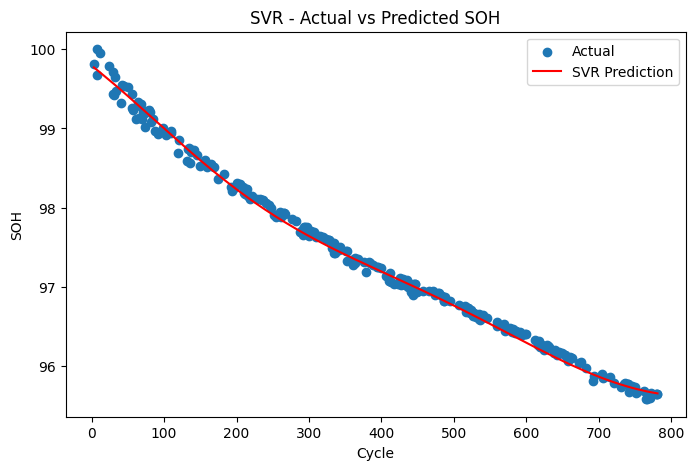

In [48]:

y_pred = model.predict(X_test)

idx = np.argsort(X_test.iloc[:, 0])

plt.figure(figsize=(8,5))

plt.scatter(
   X_test.iloc[:, 0],
    y_test,
    label="Actual"
)

plt.plot(
   X_test.iloc[idx, 0],
    y_pred[idx],
    label="SVR Prediction",
    color="red"
)

plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("SVR - Actual vs Predicted SOH")
plt.legend()
plt.show()

In [58]:
models = {
    "Linear Regression": LinearRegression(),

    "Polynomial Regression": make_pipeline(
        PolynomialFeatures(degree=4),
        LinearRegression()
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "SVR": SVR(kernel="rbf")
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,MSE,RMSE,MAE
0,Gradient Boosting,0.997292,0.003644,0.060363,0.045854
1,Polynomial Regression,0.997275,0.003666,0.060551,0.049240
2,Random Forest,0.997262,0.003684,0.060700,0.046975
3,SVR,0.995939,0.005465,0.073925,0.060358
4,Decision Tree,0.995456,0.006114,0.078192,0.056038
5,Linear Regression,0.980803,0.025831,0.160720,0.127992
